# Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

No prepared report can tell you as much as you’ll learn by diving into the data yourself.

Loading the dataset of company that rent bicycles for short period to ride around the city.

In [2]:
hour = pd.read_csv('hour.csv')
hour.head(n = 50)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,count
0,1,01-01-2011,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,01-01-2011,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,01-01-2011,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,01-01-2011,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,01-01-2011,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,01-01-2011,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,01-01-2011,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,01-01-2011,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,01-01-2011,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,01-01-2011,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


Data science has a reputation for requiring arcane knowledge about sophisticated math and computer science, but simply glancing at a dataset, thinking a little, and applying common sense can go a long way toward improving any business scenario.

Windows filepaths look different from macOS and Linux filepaths. In macOS and Linux, we use forward slashes exclusively, and we start with a slash (/) instead of a drive name like C:\

Exploring the data types of each column

In [3]:
hour.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
count          object
dtype: object

The 'count' column is recognized as object instead of int. Let's find out why.

In [4]:
hour[hour['count'].str.strip() == '']

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,count
36,37,02-01-2011,1,0,1,13,0,0,0,2,0.36,0.3485,0.66,0.1343,11,64,
37,38,02-01-2011,1,0,1,14,0,0,0,3,0.36,0.3485,0.76,0.1940,4,55,


An empty string is a string with zero length, while a null value represents the absence of a value. Let's replace empty string with 0 and then convert the column data type to 'int',

In [5]:
blank_count_index = hour[hour['count'].str.strip() == ''].index
hour.loc[blank_count_index,'count'] = 0
hour['count'] = hour['count'].astype(int)

hour.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

Let's compute average rides per hour.

In [6]:
hour['count'].mean()

np.float64(189.4553771793544)

Let's compute the central value of the hourly riders' distribution.

In [7]:
hour['count'].median()

142.0

What is the standard deviation from hourly average riders?

In [8]:
hour['count'].std()

181.39420859113446

What is the minimum and maximum hourly registered riders count in data?

In [9]:
hour['registered'].min()

0

In [10]:
hour['registered'].max()

886

View summary statistics

In [11]:
hour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,count
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.455377
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.394209
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


You should look at the output of describe() for every dataset you work with to make sure that all the values are at least meaningful.

Let's look at the average nighttime riders

In [12]:
hour.loc[hour['hr']<5,'count'].mean() #instead of specifying the specific row index, we specified the logical condition.

np.float64(25.919640348412475)

Let's check the counts for colder and warmer early mornings.

In [13]:
hour.loc[(hour['hr'] > 3) & (hour['hr'] < 7) & (hour['temp']) < 0.5, 'count'].mean() # In loc row condition, it is important to put individual filter conditions in parenthesis.

np.float64(211.2023622047244)

Lets compute the mean hourly ridership for either the high temperature of high humidity situations.

In [14]:
hour.loc[(hour['temp'] > 0.5) | (hour['hum'] > 0.5),'count'].mean()

np.float64(193.3584892774211)

Seasonal data

In [15]:
hour.groupby('season')['count'].mean() #try visualizing the code without .groupby(by= 'season')

season
1    111.082980
2    208.344069
3    236.016237
4    198.868856
Name: count, dtype: float64

Let's group by season as well as holidays

In [16]:
hour.groupby(['season', 'holiday'])['count'].mean() #4 seasons and 2 holiday categories(holiday or working) so output is 4*2 = 8 rows

season  holiday
1       0          112.653016
        1           72.042683
2       0          208.428472
        1          204.552083
3       0          235.976818
        1          237.822917
4       0          199.965998
        1          167.722222
Name: count, dtype: float64

You should plot your data early and often every time you’re doing data analysis.

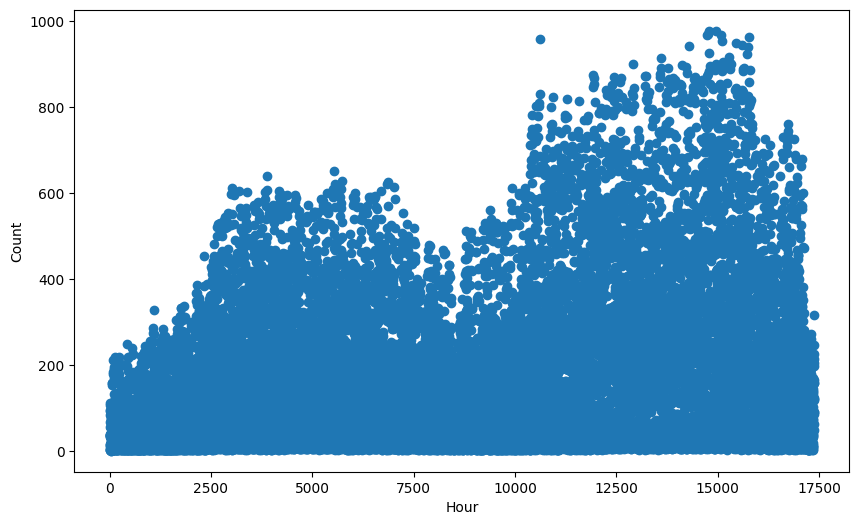

In [17]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(x = hour['instant'], y = hour['count'])
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()

The figure, fig, will contain all the information about whatever plot or group of plots we draw.  
The axis, ax, will give us access to useful methods for actually drawing plots.  
The subplots() method creates both of these. Figure size of (10,6), meaning that our figure will have a width of 10 inches and a height of 6 inches.  
scatterplot, is a good first plot to draw because it shows every observation in the data; it also makes relationships easy to visually identify. In this case, we can see a full representation of the seasonal variation that our groupby() statement previously gave us a hint about. We can also see the general growth of ridership over time.


Let's scatter plot the data of first day

In [18]:
first_day_data = hour.loc[0:24,['instant', 'registered', 'casual' , 'count']]
first_day_data.head()

,instant,registered,casual,count
0,1,13,3,16
1,2,32,8,40
2,3,27,5,32
3,4,10,3,13
4,5,1,0,1


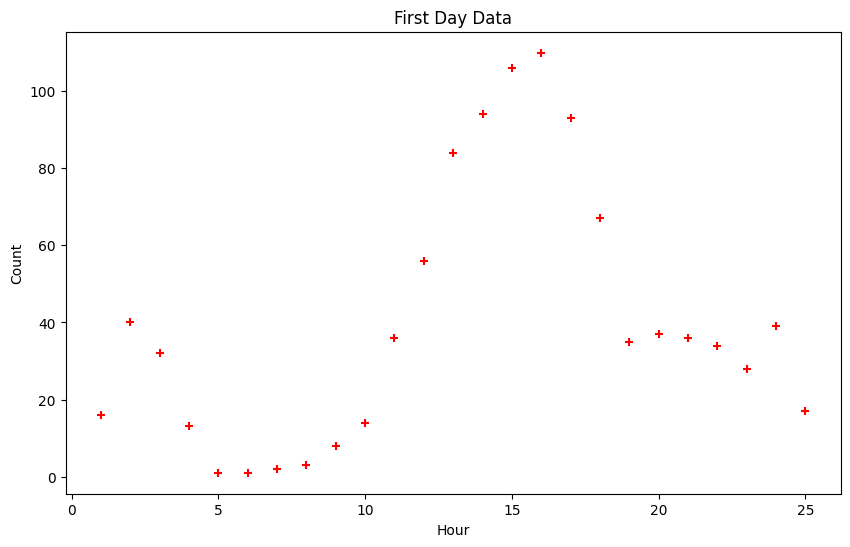

In [19]:
fig, ax = plt.subplots(figsize = (10,6))
ax.scatter(x=first_day_data['instant'], y=first_day_data['count'], marker = '+', c = 'r')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.title('First Day Data')
plt.show()

When you have a big dataset, it’s a good idea to do both: plot the entire dataset at once (to understand the general, overall patterns) as well as plot smaller subsets of the data (to understand individual observations and smaller-scale patterns).

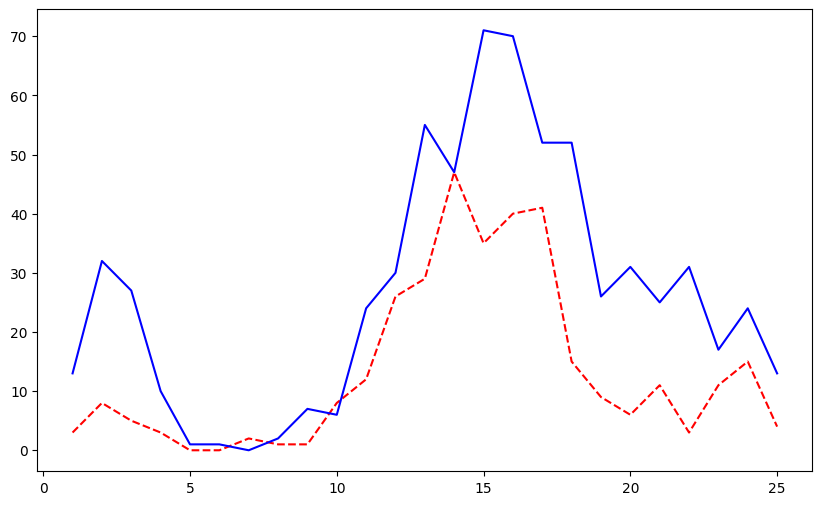

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(first_day_data['instant'],first_day_data['casual'],c='red',label='casual',linestyle='--')
ax.plot(first_day_data['instant'],first_day_data['registered'],c='blue',label='registered',linestyle='-')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

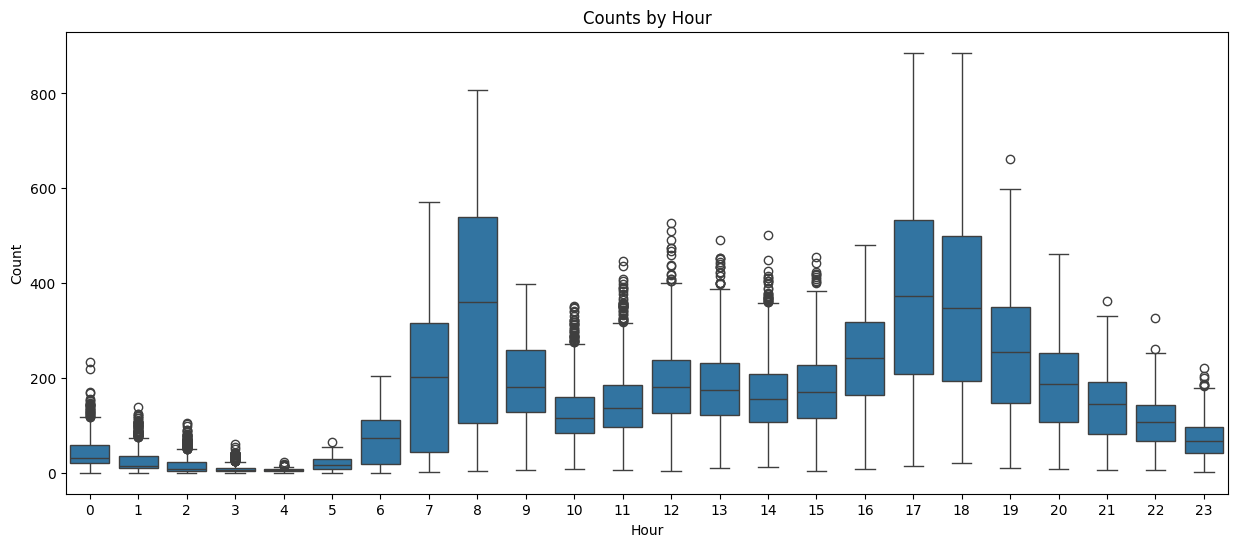

In [21]:
fig, ax = plt.subplots(figsize=(15,6))
sns.boxplot(x = 'hr', y = 'registered', data=hour)
plt.xlabel('Hour')
plt.ylabel('Count')
plt.title('Counts by Hour')
plt.show

In a box plot, the upper and lower horizontal boundaries of each rectangle represent the 75th and 25th percentiles of the plotted data, respectively. The horizontal line inside the rectangle represents the median (or 50th percentile). The vertical lines extending from the top and bottom of each rectangle represent the full range of all observations that are not considered outliers. The individually drawn points beyond the ranges of the vertical lines are regarded as outliers.

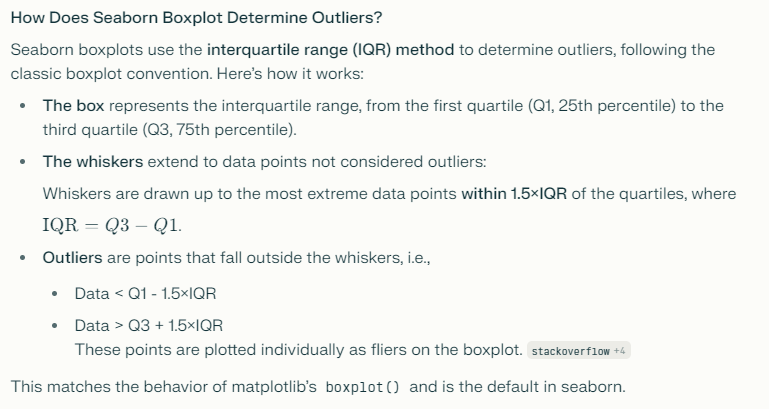

[]

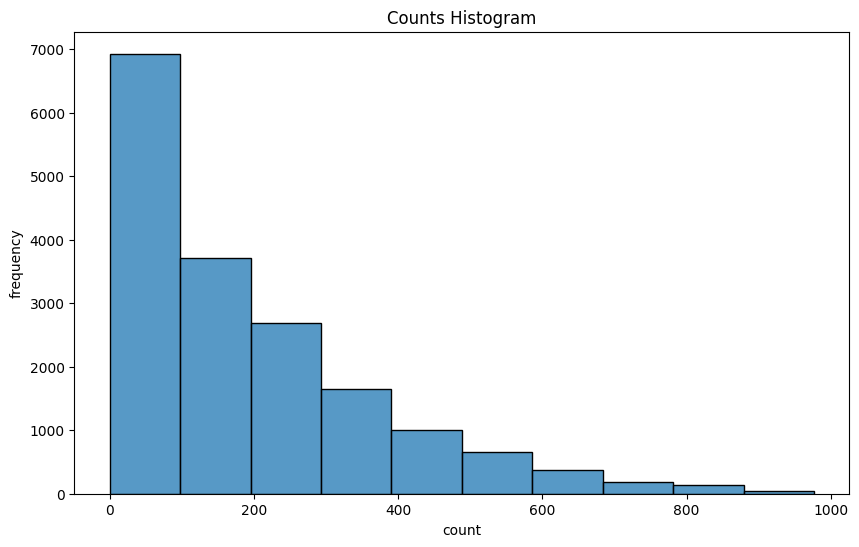

In [22]:
fig, ax = plt.subplots(figsize = (10,6))
sns.histplot(data=hour, x = 'count', bins=10)
plt.xlabel('count')
plt.ylabel('frequency')
plt.title('Counts Histogram')
plt.plot()

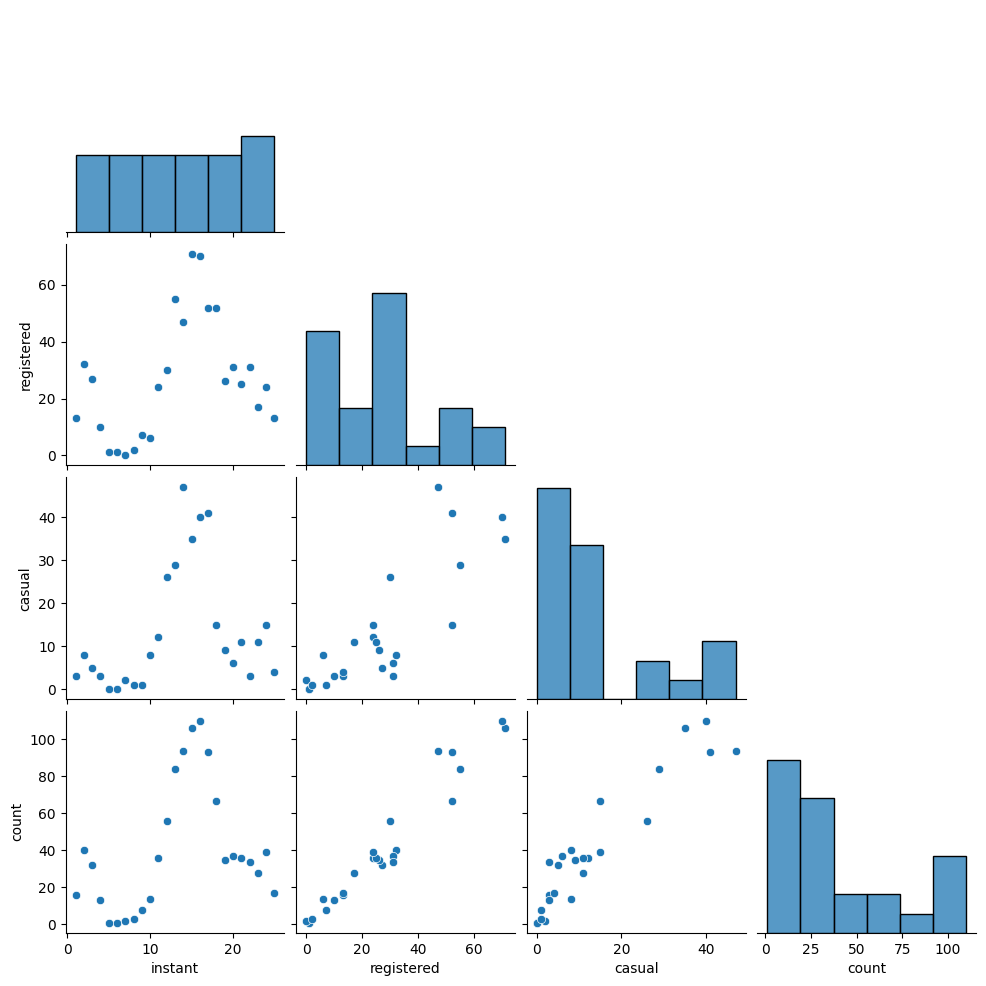

In [23]:
sns.pairplot(first_day_data, corner=True)
plt.show()

Correlation

In [24]:
hour['casual'].corr(hour['registered'])

np.float64(0.5066177004294635)

In [25]:
hour['temp'].corr(hour['hum'])

np.float64(-0.06988139105119355)

The Pearson correlation coefficient is a number that’s always between –1 and 1, and it’s often named with the variable r. If the correlation coefficient is 0, or very close to 0, we say that the variables are uncorrelated. We pay attention to their exact magnitude.

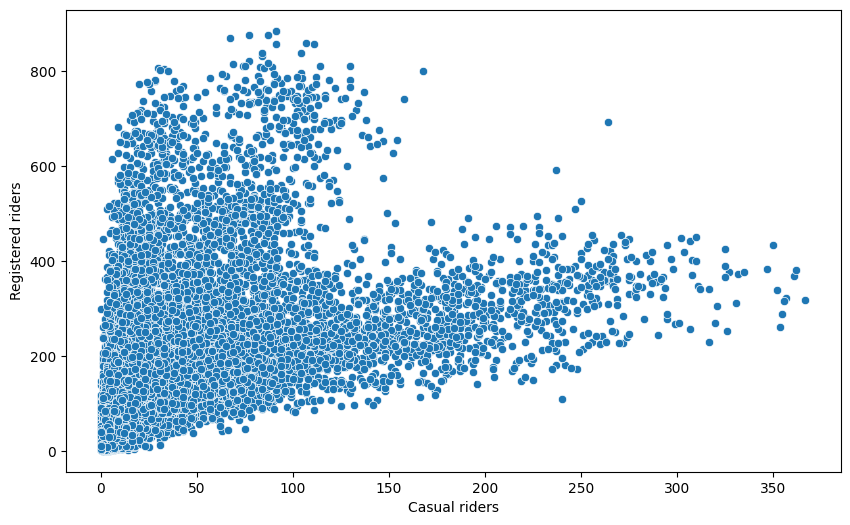

In [26]:
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=hour, x='casual', y='registered')
plt.xlabel('Casual riders')
plt.ylabel('Registered riders')
plt.show()

The relationship between casual and registered ridership is not deterministic. Often a higher number of casual riders corresponds to a higher number of registered riders. But sometimes it doesn’t; we can’t perfectly predict one variable by using the other one. When two variables are correlated but don’t have a deterministic relationship, we say that the relationship between the two variables has “noise,” or randomness.  
  
Randomness is hard to define precisely, but you can think of it as unpredictability.  
  
You can think of the size of the correlation coefficient as a measure of the amount of randomness in the relationship between two variables. A larger correlation coefficient corresponds to less randomness. You can think of a 0 correlation coefficient, indicating no relationship at all between variables, as an indication of pure randomness, or pure noise.

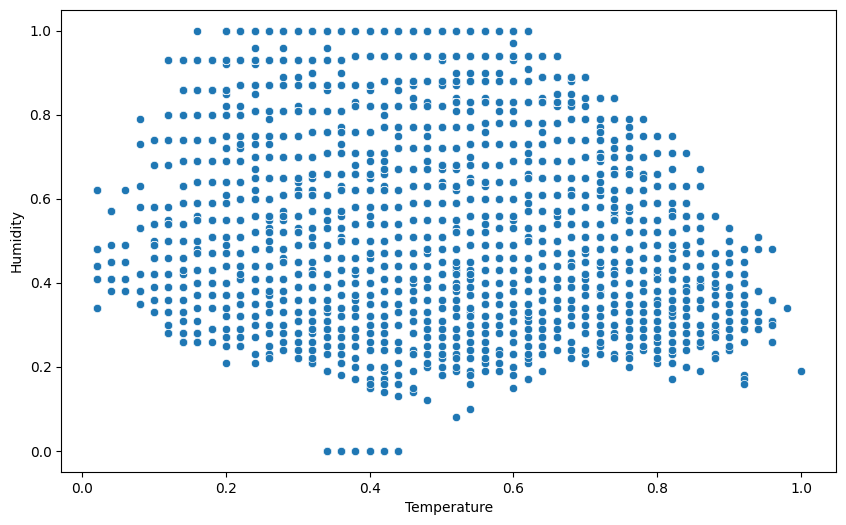

In [27]:
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=hour, y='hum', x='temp')
plt.ylabel('Humidity')
plt.xlabel('Temperature')
plt.show()

### "Correlation does not imply causation!!"

Creating a correlation matrix can be a quick, simple way to find correlations among all the variables in your data and find any surprising positive or negative correlations.

In [31]:
hour.loc[:, ['hr', 'temp', 'windspeed']].corr()

,hr,temp,windspeed
hr,1.000000,0.137603,0.137252
temp,0.137603,1.000000,-0.023125
windspeed,0.137252,-0.023125,1.000000


Creating heat maps

Let's create heat map of all these correlations

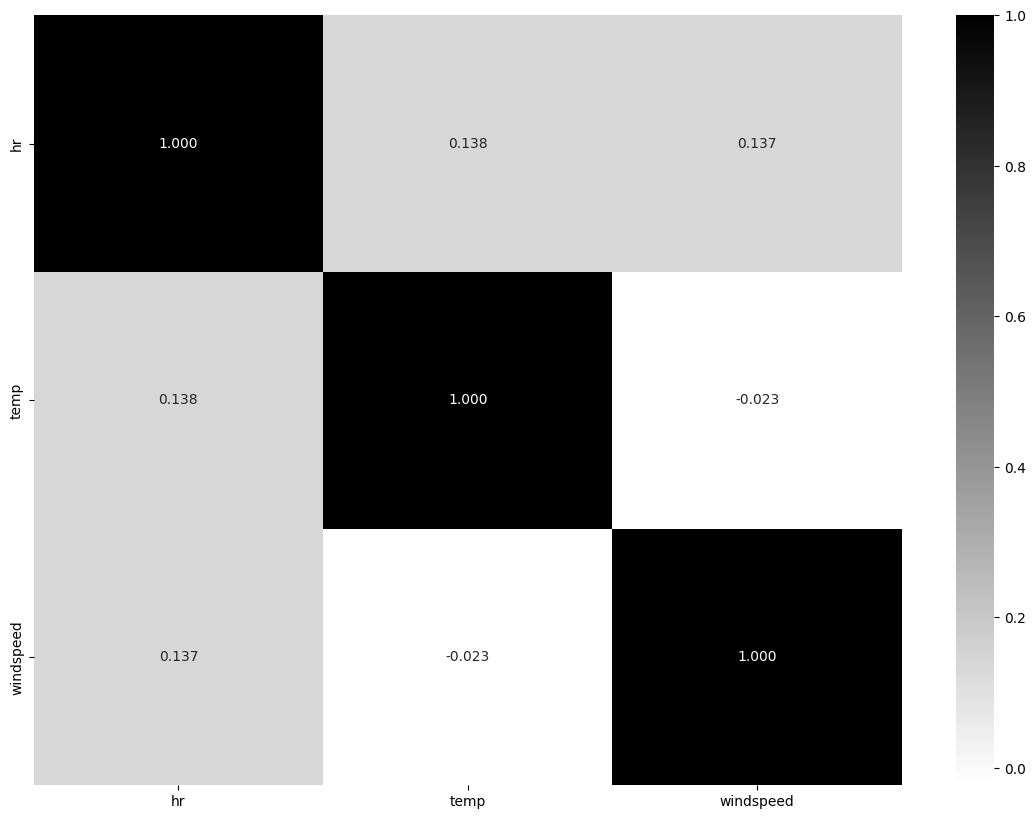

In [36]:
plt.figure(figsize=(14,10))
variables = ['hr', 'temp', 'windspeed']
corr = hour[variables].corr()
sns.heatmap(corr, annot=True, cmap='binary', fmt = ".3f", xticklabels=variables, yticklabels=variables)
plt.show()

In [38]:
df_hm = hour.pivot_table(index='hr', columns='weekday',values='count')
df_hm

weekday,0,1,2,3,4,5,6
hr,,,,,,,
0,93.990385,34.009524,27.623762,34.557692,39.271845,52.432692,94.304762
1,77.432692,17.307692,12.540000,15.336538,17.223301,24.721154,67.780952
2,61.627451,10.313131,6.801980,7.813725,9.156863,12.740385,50.495238
3,31.144231,5.113402,4.152174,4.888889,5.071429,6.598039,22.885714
4,9.362745,5.785714,5.131313,4.968750,5.280000,6.072165,7.657143
5,8.693878,21.653846,24.455446,25.750000,25.912621,23.903846,8.291262
6,14.495146,85.865385,106.500000,107.807692,107.436893,90.028846,21.000000
7,33.104762,248.538462,299.696078,303.980769,304.737864,254.326923,45.961905
8,83.857143,412.192308,471.784314,488.326923,488.572816,462.278846,114.476190


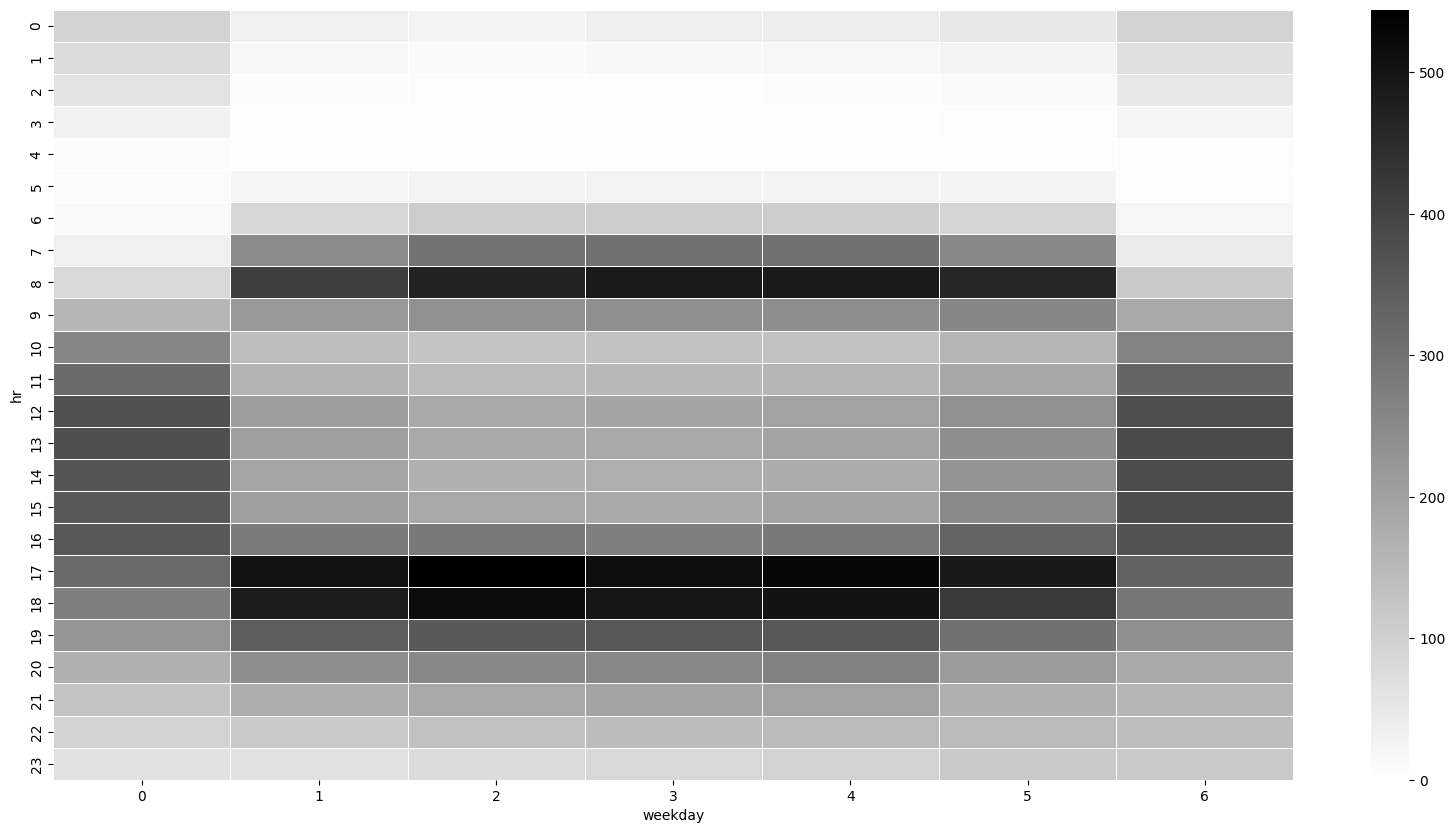

In [39]:
plt.figure(figsize = (20,10))
sns.heatmap(df_hm, fmt='d', cmap='binary', linewidths=0.5, vmin=0)
plt.show()